# Step 4: Hysteresis in the time-dependent model

Does my time-dependent model show the hysteresis loop that Schoof's theory predicts in step 1? I lower the rate factor A step by step through the MISMIP values and then raise it again, running each value to steady state before changing A. If the model follows the theory, the grounding line should jump forward across the overdeepening on the way down, and back on the way up, at different values of A.

I load the libraries and model functions and set the parameters. I use the sub-grid scheme at 1 km, the best configuration I can run in reasonable time (step 3: 6.4 km short of Schoof at A = 3e-25). The 13 values of A are MISMIP EXP 3a, Table 5. Units: metres and years.

In [1]:
%matplotlib inline

import os
import time

import numpy as np
import matplotlib.pyplot as plt

from flowline import (a_per_year, bed, bed_slope, make_grid, surface_elevation, run_to_steady_state,
                      schoof_steady_positions)
from scipy.optimize import brentq

A_SEQUENCE_SI = [3e-25, 2.5e-25, 2e-25, 1.5e-25, 1e-25, 5e-26, 2.5e-26,    # A going down (Pa^-3 s^-1)
                 5e-26, 1e-25, 1.5e-25, 2e-25, 2.5e-25, 3e-25]             # and back up
DX = 1e3                      # grid spacing (m)
SCHEME = "subgrid"            # sub-grid grounding line (step 3)
X_CALVING = 1600e3            # fixed calving front (m)
H_INITIAL = 10.0              # the first step starts from a 10 m layer of ice (m), as in MISMIP
CHECK_EVERY = 100.0           # test for steady state, and save the profile, every 100 years
XG_RATE_TOL = 0.1             # steady: grounding line moves less than 0.1 m/yr ...
DHDT_TOL = 1e-4               # ... and thickness changes less than 0.1 mm/yr on average
MAX_YEARS_PER_STEP = 80000.0  # give up on a step after this long (yr)
CFL = 0.5
DT_MAX = 10.0
FIG_DIR = "../figures"
DATA_DIR = "../data"

x_edges, x_centres = make_grid(X_CALVING, DX)
x_od1 = brentq(bed_slope, 800e3, 1100e3)      # the overdeepening, as in step 1
x_od2 = brentq(bed_slope, 1100e3, 1400e3)
print(f"{len(x_centres)} cells of {DX / 1e3:g} km; overdeepening from {x_od1 / 1e3:.1f} to {x_od2 / 1e3:.1f} km")

1600 cells of 1 km; overdeepening from 973.7 to 1265.7 km


## Running the sequence

Each value of A starts from the final ice sheet of the previous value (the first from the 10 m layer) and runs until the grounding line moves less than 0.1 m/yr and the thickness changes less than 0.1 mm/yr, checked every 100 years. For each step I also list Schoof's stable states for that A, and which one the model is closest to. I keep the profile every 100 years only for the steps where the grounding line jumps, which I define as starting on one side of the overdeepening and ending on the other.

In [2]:
steps = []
h = np.full(len(x_centres), H_INITIAL)
u = None
for k, a_si in enumerate(A_SEQUENCE_SI):
    direction = "start" if k == 0 else ("down" if a_si < A_SEQUENCE_SI[k - 1] else "up")
    start = time.time()
    r = run_to_steady_state(h, x_centres, DX, a_per_year(a_si), SCHEME, max_years=MAX_YEARS_PER_STEP,
                            check_every=CHECK_EVERY, xg_rate_tol=XG_RATE_TOL, dhdt_tol=DHDT_TOL, cfl=CFL,
                            dt_max=DT_MAX, u_guess=u, keep_profiles=True)
    wall = time.time() - start
    schoof = [xg for xg, stable in schoof_steady_positions(a_per_year(a_si), 480e3, 1800e3) if stable]
    nearest = min(schoof, key=lambda xs: abs(xs - r["x_g"][-1]))
    # a jump: the grounding line starts on one side of the overdeepening and ends on the other
    jumped = (r["x_g"][0] < x_od1 and r["x_g"][-1] > x_od2) or (r["x_g"][0] > x_od2 and r["x_g"][-1] < x_od1)
    steps.append({"step": k + 1, "A": a_si, "direction": direction, "x_start": r["x_g"][0], "x_end": r["x_g"][-1],
                  "years": r["years"], "steady": r["steady"], "wall": wall, "schoof": schoof, "nearest": nearest,
                  "time": r["time"], "x_g": r["x_g"], "profiles": r["profiles"] if jumped else None, "jumped": jumped})
    print(f"step {k + 1:2d} A = {a_si:.1e} ({direction:5s}): x_g {r['x_g'][0] / 1e3:7.1f} -> {r['x_g'][-1] / 1e3:7.1f} km "
          f"| Schoof stable: {', '.join(f'{xs / 1e3:.1f}' for xs in schoof)} km | error {(r['x_g'][-1] - nearest) / 1e3:+6.1f} km "
          f"| steady {r['steady']} after {r['years']:.0f} yr | {wall:.0f} s{'  JUMP' if jumped else ''}")
    h = r["h"]
    u = r["u"]
print(f"total model time {sum(s['years'] for s in steps):.0f} years, total run time {sum(s['wall'] for s in steps) / 60:.1f} minutes")

step  1 A = 3.0e-25 (start): x_g   482.4 ->   715.5 km | Schoof stable: 721.9 km | error   -6.4 km | steady True after 21700 yr | 44 s


step  2 A = 2.5e-25 (down ): x_g   715.5 ->   725.5 km | Schoof stable: 732.1 km | error   -6.6 km | steady True after 7500 yr | 10 s


step  3 A = 2.0e-25 (down ): x_g   725.5 ->   739.4 km | Schoof stable: 745.7, 1307.8 km | error   -6.3 km | steady True after 9300 yr | 12 s


step  4 A = 1.5e-25 (down ): x_g   739.4 ->   758.5 km | Schoof stable: 765.5, 1346.1 km | error   -7.0 km | steady True after 9500 yr | 12 s


step  5 A = 1.0e-25 (down ): x_g   758.5 ->   792.5 km | Schoof stable: 799.8, 1376.3 km | error   -7.3 km | steady True after 12300 yr | 16 s


...

step  9 A = 1.0e-25 (up   ): x_g  1407.1 ->  1372.1 km | Schoof stable: 799.8, 1376.3 km | error   -4.2 km | steady True after 16500 yr | 15 s


step 10 A = 1.5e-25 (up   ): x_g  1372.1 ->  1343.0 km | Schoof stable: 765.5, 1346.1 km | error   -3.1 km | steady True after 17000 yr | 18 s


step 11 A = 2.0e-25 (up   ): x_g  1343.0 ->  1307.9 km | Schoof stable: 745.7, 1307.8 km | error   +0.1 km | steady True after 19700 yr | 25 s


step 12 A = 2.5e-25 (up   ): x_g  1307.9 ->   730.9 km | Schoof stable: 732.1 km | error   -1.2 km | steady True after 26700 yr | 90 s  JUMP


step 13 A = 3.0e-25 (up   ): x_g   730.9 ->   720.9 km | Schoof stable: 721.9 km | error   -0.9 km | steady True after 7900 yr | 10 s
total model time 221500 years, total run time 5.5 minutes


I save the table of steps to `data/hysteresis_steps.csv`.

In [3]:
with open(os.path.join(DATA_DIR, "hysteresis_steps.csv"), "w") as f:
    f.write("step,A_Pa-3_s-1,direction,x_g_start_km,x_g_end_km,schoof_nearest_km,error_km,years,steady,run_time_s\n")
    for s in steps:
        f.write(f"{s['step']},{s['A']:.2e},{s['direction']},{s['x_start'] / 1e3:.2f},{s['x_end'] / 1e3:.2f},"
                f"{s['nearest'] / 1e3:.2f},{(s['x_end'] - s['nearest']) / 1e3:.2f},{s['years']:.0f},{s['steady']},{s['wall']:.1f}\n")
print("saved data/hysteresis_steps.csv")

saved data/hysteresis_steps.csv


The steady grounding lines of my model on top of Schoof's curve from step 1 (solid stable, dashed unstable). Downward triangles are steps where A was lowered, upward triangles steps where it was raised.

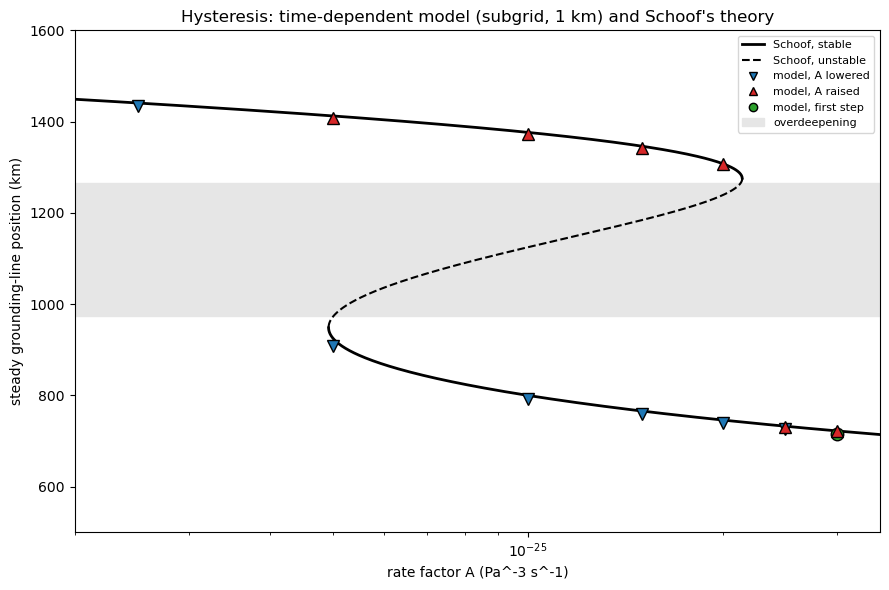

In [4]:
curve = np.loadtxt(os.path.join(DATA_DIR, "schoof_steady_states.csv"), delimiter=",", skiprows=1)
xg_curve, a_curve, stable_curve = curve[:, 0], curve[:, 1], curve[:, 2] > 0.5

fig, ax = plt.subplots(figsize=(9, 6))
start = 0
labels_done = set()
for i in range(1, len(xg_curve) + 1):
    if i == len(xg_curve) or stable_curve[i] != stable_curve[start]:
        seg = slice(start, i)
        label = "Schoof, stable" if stable_curve[start] else "Schoof, unstable"
        ax.plot(a_curve[seg], xg_curve[seg], color="k", lw=2 if stable_curve[start] else 1.5,
                ls="-" if stable_curve[start] else "--", label=None if label in labels_done else label)
        labels_done.add(label)
        start = i
for s in steps:
    marker = {"start": "o", "down": "v", "up": "^"}[s["direction"]]
    color = {"start": "tab:green", "down": "tab:blue", "up": "tab:red"}[s["direction"]]
    ax.plot(s["A"], s["x_end"] / 1e3, marker, ms=9, color=color, mec="k")
ax.plot([], [], "v", color="tab:blue", mec="k", label="model, A lowered")
ax.plot([], [], "^", color="tab:red", mec="k", label="model, A raised")
ax.plot([], [], "o", color="tab:green", mec="k", label="model, first step")
ax.axhspan(x_od1 / 1e3, x_od2 / 1e3, color="0.9", label="overdeepening")
ax.set_xscale("log")
ax.set_xlim(2e-26, 3.5e-25)
ax.set_ylim(500, 1600)
ax.set_xlabel("rate factor A (Pa^-3 s^-1)")
ax.set_ylabel("steady grounding-line position (km)")
ax.set_title(f"Hysteresis: time-dependent model ({SCHEME}, {DX / 1e3:g} km) and Schoof's theory")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_hysteresis.png"), dpi=150)
plt.show()

## The jumps across the overdeepening

For each step where the grounding line jumped, I look at how the jump unfolds in time: how long the grounding line takes to cross the overdeepening and how fast it moves at its fastest.

In [5]:
for s in steps:
    if not s["jumped"]:
        continue
    t, xg = s["time"], s["x_g"]
    speed = np.abs(np.diff(xg)) / np.diff(t)                      # average over each 100-year interval
    fastest = np.argmax(speed)
    if s["x_end"] > s["x_start"]:
        enter = t[np.argmax(xg > x_od1)]
        leave = t[np.argmax(xg > x_od2)]
    else:
        enter = t[np.argmax(xg < x_od2)]
        leave = t[np.argmax(xg < x_od1)]
    print(f"step {s['step']} (A = {s['A']:.1e}, {s['direction']}): {s['x_start'] / 1e3:.1f} -> {s['x_end'] / 1e3:.1f} km | "
          f"crossed the overdeepening between year {enter:.0f} and {leave:.0f} ({leave - enter:.0f} years) | "
          f"average speed across it {(x_od2 - x_od1) / (leave - enter):.0f} m/yr | fastest {speed[fastest]:.0f} m/yr (100-year average), "
          f"between year {t[fastest]:.0f} and {t[fastest + 1]:.0f}, near {0.5 * (xg[fastest] + xg[fastest + 1]) / 1e3:.0f} km")

step 7 (A = 2.5e-26, down): 908.5 -> 1433.5 km | crossed the overdeepening between year 1600 and 7400 (5800 years) | average speed across it 50 m/yr | fastest 80 m/yr (100-year average), between year 0 and 100, near 912 km
step 12 (A = 2.5e-25, up): 1307.9 -> 730.9 km | crossed the overdeepening between year 3800 and 11300 (7500 years) | average speed across it 39 m/yr | fastest 167 m/yr (100-year average), between year 11100 and 11200, near 982 km


The grounding line against time during each jump. The grey band is the overdeepening.

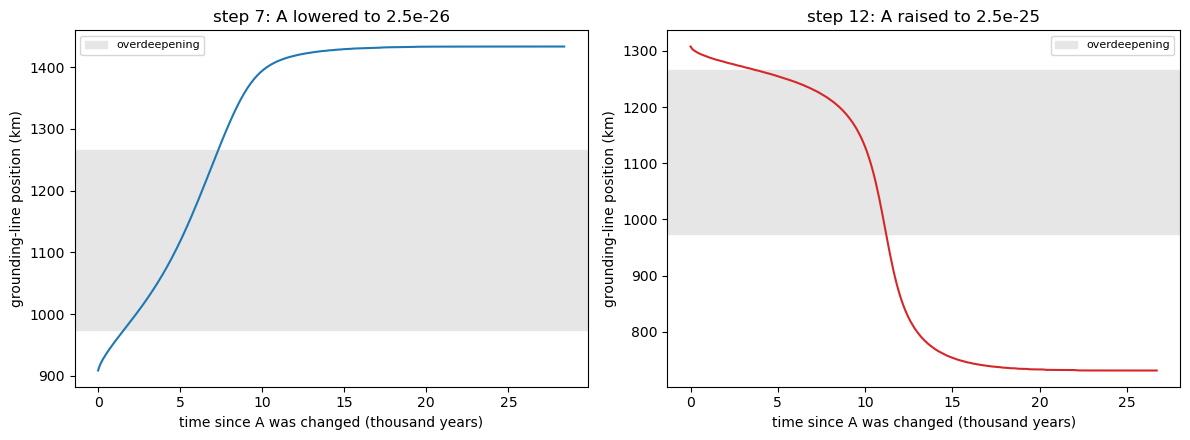

In [6]:
jumps = [s for s in steps if s["jumped"]]
fig, axes = plt.subplots(1, len(jumps), figsize=(6 * len(jumps), 4.5), squeeze=False)
for ax, s in zip(axes[0], jumps):
    ax.plot(s["time"] / 1e3, s["x_g"] / 1e3, color="tab:blue" if s["direction"] == "down" else "tab:red")
    ax.axhspan(x_od1 / 1e3, x_od2 / 1e3, color="0.9", label="overdeepening")
    ax.set_xlabel("time since A was changed (thousand years)")
    ax.set_ylabel("grounding-line position (km)")
    ax.set_title(f"step {s['step']}: A {'lowered' if s['direction'] == 'down' else 'raised'} to {s['A']:.1e}")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_jump_gl_vs_time.png"), dpi=150)
plt.show()

Ice profiles during the advance across the overdeepening: the steady profile before the jump, a few profiles during it, and the steady profile after.

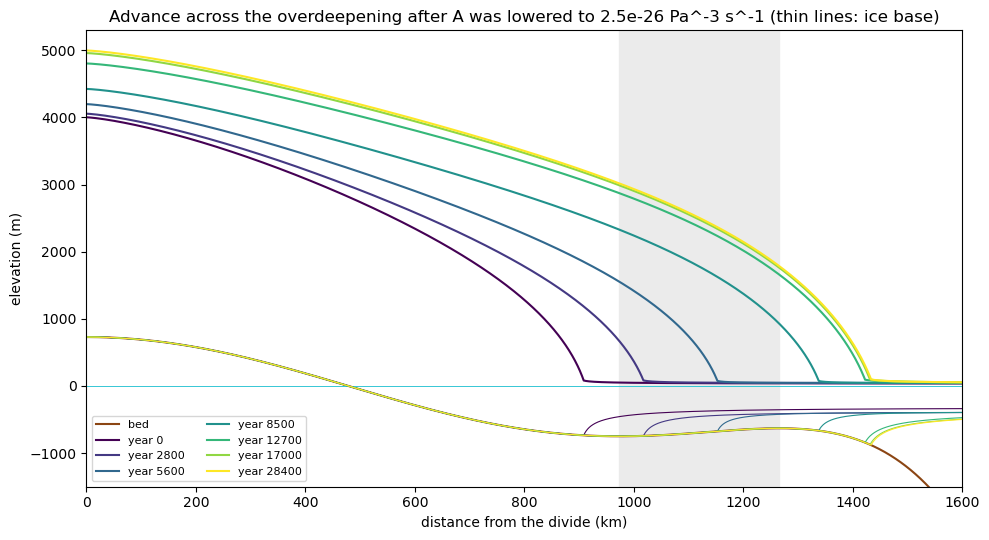

In [7]:
advance = [s for s in jumps if s["direction"] == "down"][0]
n_prof = len(advance["profiles"])
picks = [0] + [int(f * (n_prof - 1)) for f in (0.1, 0.2, 0.3, 0.45, 0.6)] + [n_prof - 1]
colors = plt.cm.viridis(np.linspace(0, 1, len(picks)))
b_c = bed(x_centres)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(x_centres / 1e3, b_c, color="saddlebrown", label="bed")
ax.axhline(0, color="tab:cyan", lw=0.6)
for idx, color in zip(picks, colors):
    hp = advance["profiles"][idx]
    s_p = surface_elevation(hp, b_c)
    ax.plot(x_centres / 1e3, s_p, color=color, label=f"year {advance['time'][idx]:.0f}")
    ax.plot(x_centres / 1e3, s_p - hp, color=color, lw=0.8)
ax.axvspan(x_od1 / 1e3, x_od2 / 1e3, color="0.92")
ax.set_xlim(0, X_CALVING / 1e3)
top = max(np.max(surface_elevation(advance['profiles'][idx], b_c)) for idx in picks)
ax.set_ylim(-1500, top + 300)
ax.set_xlabel("distance from the divide (km)")
ax.set_ylabel("elevation (m)")
ax.set_title(f"Advance across the overdeepening after A was lowered to {advance['A']:.1e} Pa^-3 s^-1 (thin lines: ice base)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_jump_profiles.png"), dpi=150)
plt.show()